In [ ]:
import ee
import geemap

# 1. Triggers the authentication flow (opens your browser to log in)
ee.Authenticate()

# 2. Initialize Earth Engine with your Project ID
ee.Initialize(project='Your-Project-ID')

print("Earth Engine initialized successfully!")


Earth Engine initialized successfully!


In [2]:
# Define the center coordinates of your city [Longitude, Latitude]
city_center = ee.Geometry.Point([72.8774, 19.0760])

# Create a 20km radius buffer around the center to capture the urban and suburban area
aoi = city_center.buffer(20000)

In [3]:
def prep_landsat8(image):
    # 1. CLOUD MASKING: 
    # 31 in binary is 11111. This checks Bit 0 (Fill), Bit 1 (Dilated Cloud), 
    # Bit 2 (Cirrus), Bit 3 (Cloud), and Bit 4 (Cloud Shadow).
    # .eq(0) ensures all these bits are clear (no clouds/shadows).
    qa = image.select('QA_PIXEL')
    qa_mask = qa.bitwiseAnd(31).eq(0)
    
    # 2. SCALING FACTORS:
    # Scale optical bands (B1-B7) to Surface Reflectance
    optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    
    # Scale thermal band (B10) to Kelvin
    thermal_band = image.select('ST_B10').multiply(0.00341802).add(149.0)
    
    # Replace original bands with scaled bands and apply the cloud mask
    return image.addBands(optical_bands, None, True) \
                .addBands(thermal_band, None, True) \
                .updateMask(qa_mask)

In [8]:
# Load Landsat 8 Surface Reflectance/Temperature Collection
l8_collection = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
                 .filterBounds(aoi)
                 .filterDate('2026-03-01', '2026-05-31') # Adjust to your city's summer
                 .filter(ee.Filter.lt('CLOUD_COVER', 20)) # Pre-filter super cloudy days
                 .map(prep_landsat8))

# Compress the time-series into a single median image and clip it to our city border
median_image = l8_collection.median().clip(aoi)

In [9]:
# Create an interactive map centered on your AOI
Map = geemap.Map(center=[19.0760, 72.8774], zoom=11)

# Visualization parameters for a True Color (RGB) composite
vis_params_true = {
    'bands': ['SR_B4', 'SR_B3', 'SR_B2'], # Red, Green, Blue
    'min': 0.0,
    'max': 0.3,
}

# Add the processed image to the map
Map.addLayer(median_image, vis_params_true, 'Cloud-Free True Color')

# Add a rectangle showing your exact AOI boundaries
Map.addLayer(aoi, {'color': 'red'}, 'City Boundaries (AOI)', opacity=0.4)

Map.addLayerControl()
Map

Map(center=[19.076, 72.8774], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprig…

In [10]:
# 1. Calculate NDVI: (NIR - Red) / (NIR + Red)
# Landsat 8 NIR = Band 5, Red = Band 4
ndvi = median_image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')

# 2. Calculate NDBI: (SWIR1 - NIR) / (SWIR1 + NIR)
# Landsat 8 SWIR1 = Band 6, NIR = Band 5
ndbi = median_image.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')

# 3. Convert Land Surface Temperature (LST) from Kelvin to Celsius
# The preprocessing step already scaled ST_B10 to Kelvin
lst_celsius = median_image.select('ST_B10').subtract(273.15).rename('LST_Celsius')

# 4. Combine all features into a single image stack
feature_image = median_image.addBands([ndvi, ndbi, lst_celsius])

In [14]:
# Create a new map to display the temperature gradient
lst_map = geemap.Map(center=[19.0760, 72.8774], zoom=11)

# Visualization parameters for LST (adjust min and max based on summer temps)
lst_vis = {
    'min': 25.0, # Minimum expected Celsius
    'max': 45.0, # Maximum expected Celsius
    'palette': ['blue', 'cyan', 'green', 'yellow', 'red'] # Cool to Hot
}

# Add the LST layer to the map
lst_map.addLayer(feature_image.select('LST_Celsius'), lst_vis, 'Land Surface Temp (C)')
lst_map.addLayerControl()

lst_map


Map(center=[19.076, 72.8774], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprig…

In [16]:
import pandas as pd

# 1. Add Latitude and Longitude as bands to the image
# This ensures they get extracted as standard columns for our Pandas DataFrame
latlon_image = ee.Image.pixelLonLat()
feature_image_with_coords = feature_image.addBands(latlon_image)

# 2. Sample 10,000 random pixels within our city boundary
# scale=30 matches the native 30-meter resolution of Landsat 8
print("Extracting 10,000 points from Earth Engine (this may take a minute)...")
sampled_data = feature_image_with_coords.sample(
    region=aoi, 
    scale=30, 
    numPixels=10000, 
    seed=42, 
    geometries=False
)

# 3. Convert the Earth Engine FeatureCollection to a Pandas DataFrame
df = geemap.ee_to_df(sampled_data)

# 4. Clean the data: Drop any rows where clouds/water were masked out (NaN values)
df = df.dropna()

# 5. Rename columns for clarity
df = df.rename(columns={'longitude': 'Longitude', 'latitude': 'Latitude'})

# Display the first few rows of your new Machine Learning dataset!
df.head()

Extracting 10,000 points from Earth Engine (this may take a minute)...


,LST_Celsius,NDBI,NDVI,QA_PIXEL,QA_RADSAT,SR_B1,SR_B2,SR_B3,SR_B4,SR_B5,...,ST_B10,ST_CDIST,ST_DRAD,ST_EMIS,ST_EMSD,ST_QA,ST_TRAD,ST_URAD,Latitude,Longitude
0,29.413094,0.287038,-0.354916,21952,0,0.000337,0.017511,0.057702,0.030918,0.014720,...,302.563094,861.5,1205.0,9880.0,0,214.0,9522.0,2579.0,18.978752,72.781998
1,45.469243,0.069618,0.177790,21824,0,0.066681,0.082686,0.106570,0.122121,0.174935,...,318.619243,1200.5,1183.5,9637.0,108,232.5,11105.0,2521.0,19.065260,72.901654
2,29.544687,0.203756,-0.346005,21952,0,0.011997,0.031151,0.063326,0.040144,0.019505,...,302.694687,528.0,1197.0,9880.0,0,251.5,9577.5,2561.5,19.134789,72.754779
3,46.217789,0.077632,0.162141,21824,0,0.082343,0.091665,0.112153,0.124555,0.172763,...,319.367789,448.0,1201.0,9646.0,130,241.0,11039.0,2566.5,18.961774,72.825118
4,29.196049,0.347032,-0.415849,21952,0,0.004669,0.025321,0.056231,0.027246,0.011241,...,302.346049,684.5,1202.5,9880.0,0,216.5,9477.5,2579.0,19.093557,72.702497


In [17]:
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Define your features (Predictors) and target (LST)
X = df[['NDVI', 'NDBI']]
y = df['LST_Celsius']

# 2. Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the models
print("Training models...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)

# 4. Fit the models to the training data
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# 5. Generate predictions on the unseen test data
rf_predictions = rf_model.predict(X_test)
xgb_predictions = xgb_model.predict(X_test)

# 6. Evaluate performance using RMSE and R-squared
print("\n--- Random Forest Performance ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_predictions)):.2f} °C")
print(f"R² Score: {r2_score(y_test, rf_predictions):.4f}")

print("\n--- XGBoost Performance ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, xgb_predictions)):.2f} °C")
print(f"R² Score: {r2_score(y_test, xgb_predictions):.4f}")

Training models...

--- Random Forest Performance ---
RMSE: 2.03 °C
R² Score: 0.8923

--- XGBoost Performance ---
RMSE: 1.93 °C
R² Score: 0.9023


Extracting dense urban grid for mapping...


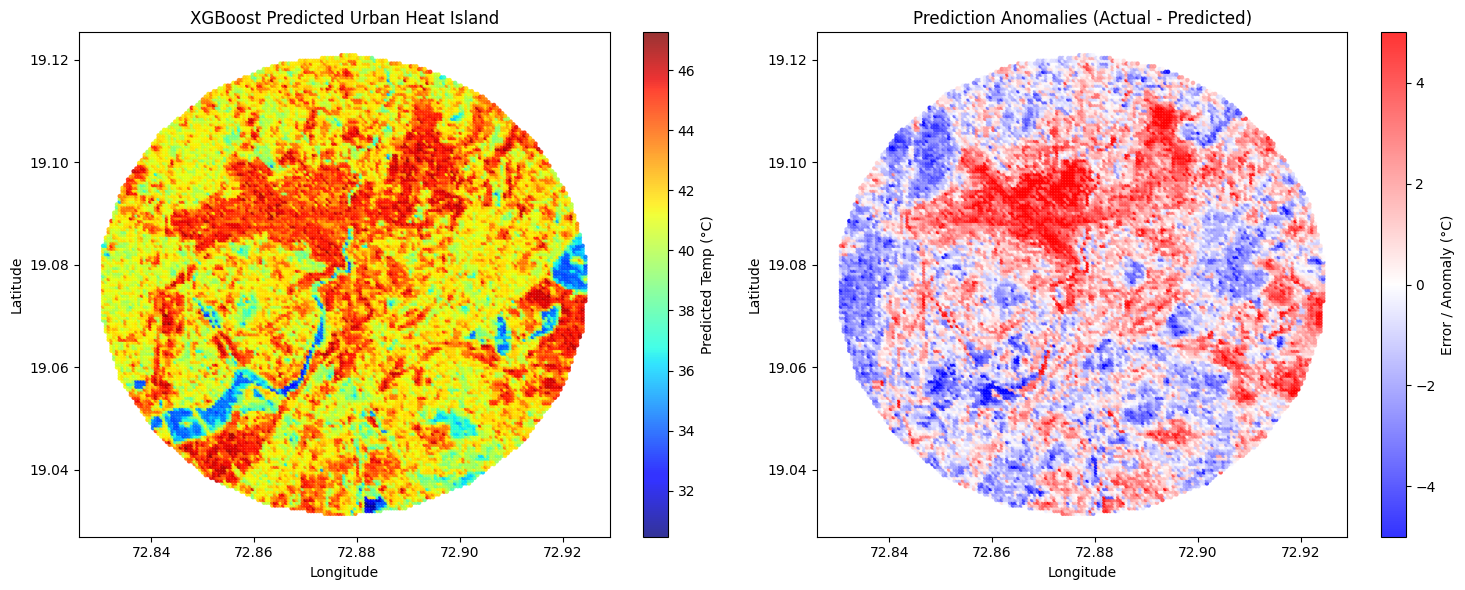

In [18]:
import matplotlib.pyplot as plt

# 1. Define a tighter 5km radius around the urban core for high-res mapping
core_urban = city_center.buffer(5000)

# 2. Extract a dense grid of 50,000 points from Earth Engine
print("Extracting dense urban grid for mapping...")
dense_sample = feature_image_with_coords.sample(
    region=core_urban,
    scale=60, # 60-meter resolution 
    numPixels=50000,
    seed=42
)

# 3. Convert to DataFrame and clean
dense_df = geemap.ee_to_df(dense_sample)
dense_df = dense_df.dropna()
dense_df = dense_df.rename(columns={'longitude': 'Longitude', 'latitude': 'Latitude'})

# 4. Predict temperatures using your trained XGBoost model
dense_df['Predicted_LST'] = xgb_model.predict(dense_df[['NDVI', 'NDBI']])

# 5. Calculate the Anomaly (Actual Temp - Predicted Temp)
# Positive anomaly = Hotter than the model expected based on vegetation/concrete
# Negative anomaly = Cooler than the model expected
dense_df['Anomaly'] = dense_df['LST_Celsius'] - dense_df['Predicted_LST']

# 6. Visualize the spatial predictions using Matplotlib
plt.figure(figsize=(15, 6))

# Plot A: The XGBoost Prediction Map
plt.subplot(1, 2, 1)
plt.scatter(dense_df['Longitude'], dense_df['Latitude'], 
            c=dense_df['Predicted_LST'], cmap='jet', s=5, alpha=0.8)
plt.colorbar(label='Predicted Temp (°C)')
plt.title('XGBoost Predicted Urban Heat Island')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Plot B: The Anomaly Map (The most important map for your portfolio)
plt.subplot(1, 2, 2)
# Using a Blue-White-Red colormap. White means the model was perfectly accurate.
plt.scatter(dense_df['Longitude'], dense_df['Latitude'], 
            c=dense_df['Anomaly'], cmap='bwr', s=5, alpha=0.8, vmin=-5, vmax=5)
plt.colorbar(label='Error / Anomaly (°C)')
plt.title('Prediction Anomalies (Actual - Predicted)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.tight_layout()
plt.show()

In [19]:
# Save your raw sampled data and your dense prediction grid
df.to_csv('uhi_training_data.csv', index=False)
dense_df.to_csv('uhi_dense_predictions.csv', index=False)
print("Data exported successfully!")

Data exported successfully!
